# Multi-Target Seq2Point NILM (Speed-Optimized)

This notebook implements a single Sequence-to-Point (Seq2Point) 1D-CNN that simultaneously disaggregates two appliances (Washing Machine and Kettle) from the aggregate mains signal. It includes several speed optimizations:
- **Training Stride:** Skips redundant windows during training.
- **Mixed Precision (AMP):** Utilizes GPU Tensor Cores for 1.5x-2x faster training.
- **Increased Batch Size & Workers:** Maximizes GPU utilization.

## 1. Setup & Configuration

In [1]:
import os
import glob
import pandas as pd
import numpy as np
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader
import matplotlib.pyplot as plt
import seaborn as sns
from sklearn.metrics import mean_absolute_error, mean_squared_error, f1_score
from tqdm.auto import tqdm
import warnings

warnings.filterwarnings('ignore')

# Set device
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f'Using device: {device}')


Using device: cuda


/data/miniconda3/envs/handwriting_gen/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


In [2]:
# Configuration Dictionary
CONFIG = {
    "window_size": 599,            
    "batch_size": 1024,            # Increased batch size for speed
    "num_workers": 4,              # Increased workers for faster dataloading
    "train_stride": 10,            # Downsample heavily redundant training windows
    "learning_rate": 1e-4,         
    "epochs": 50,                  
    "early_stopping_patience": 15,  
    
    "train_houses": [2, 3, 5, 6, 7, 8, 9],
    "val_houses": [15],
    "test_houses": [20],
    
    "data_path": "./Data",         
    "resample_seconds": "8s",      
    
    "target_appliances": ["Washing Machine", "Kettle"],
    
    "appliances": {
        "Washing Machine": {
            "max_power": 2500,     
            "on_power_threshold": 20, 
            "columns": {
                2: "Appliance2", 3: "Appliance6", 5: "Appliance3", 
                6: "Appliance2", 7: "Appliance5", 8: "Appliance4", 
                9: "Appliance3", 15: "Appliance3", 20: "Appliance4"
            }
        },
        "Kettle": {
            "max_power": 3100,
            "on_power_threshold": 2000,
            "columns": {
                2: "Appliance8", 3: "Appliance9", 5: "Appliance8", 
                6: "Appliance7", 7: "Appliance9", 8: "Appliance9", 
                9: "Appliance7", 15: "Appliance8", 20: "Appliance9"
            }
        }
    }
}


## 2. Data Loading & Preprocessing

In [3]:
def load_and_preprocess_house(house_id):
    '''Loads aggregate and multiple appliance series for a single house.'''
    file_path = os.path.join(CONFIG["data_path"], f"House_{house_id}.csv")
    if not os.path.exists(file_path):
        raise FileNotFoundError(f"File {file_path} not found.")
        
    wm_col = CONFIG["appliances"]["Washing Machine"]["columns"][house_id]
    kt_col = CONFIG["appliances"]["Kettle"]["columns"][house_id]
    
    usecols = ['Time', 'Aggregate', wm_col, kt_col]
    
    print(f"Loading House {house_id}...")
    df = pd.read_csv(file_path, usecols=usecols)
    
    df['Time'] = pd.to_datetime(df['Time'])
    df.set_index('Time', inplace=True)
    
    df = df.resample(CONFIG["resample_seconds"]).mean()
    df = df.ffill(limit=15)
    df = df.fillna(0) 
    
    df['Aggregate'] = df['Aggregate'].clip(lower=0, upper=10000)
    df[wm_col] = df[wm_col].clip(lower=0, upper=CONFIG["appliances"]["Washing Machine"]["max_power"])
    df[kt_col] = df[kt_col].clip(lower=0, upper=CONFIG["appliances"]["Kettle"]["max_power"])
    
    # Return aggregate (1D) and target appliances as a 2D array (N, 2)
    return df['Aggregate'].values, df[[wm_col, kt_col]].values

def load_split(houses):
    agg_list, app_list = [], []
    for h in houses:
        agg, app = load_and_preprocess_house(h)
        agg_list.append(agg)
        app_list.append(app)
    return np.concatenate(agg_list), np.concatenate(app_list, axis=0)


## 3. Dataset & DataLoader (Multi-Target)

In [4]:
class MultiNILMDataset(Dataset):
    def __init__(self, aggregate, appliances, window_size=599, mean=None, std=None, stride=1):
        self.window_size = window_size
        self.midpoint = window_size // 2
        self.stride = stride
        
        if mean is None or std is None:
            self.mean = np.mean(aggregate)
            self.std = np.std(aggregate)
            if self.std == 0: self.std = 1e-6
        else:
            self.mean = mean
            self.std = std
            
        self.aggregate = (aggregate - self.mean) / self.std
        self.appliances = appliances  # Shape: (N, 2)
        
        self.length = (len(self.aggregate) - self.window_size) // self.stride + 1
        
    def __len__(self):
        return self.length
        
    def __getitem__(self, idx):
        actual_idx = idx * self.stride
        x = self.aggregate[actual_idx : actual_idx + self.window_size]
        # Target: Vector of size 2 at the midpoint
        y = self.appliances[actual_idx + self.midpoint]
        return torch.FloatTensor(x).unsqueeze(0), torch.FloatTensor(y)

def create_dataloaders():
    print("\n--- Preparing data ---")
    train_agg, train_app = load_split(CONFIG["train_houses"])
    val_agg, val_app = load_split(CONFIG["val_houses"])
    test_agg, test_app = load_split(CONFIG["test_houses"])
    
    # Apply stride=10 to training to vastly speed up iterations, keep stride=1 for val/test
    train_dataset = MultiNILMDataset(train_agg, train_app, window_size=CONFIG["window_size"], stride=CONFIG["train_stride"])
    val_dataset = MultiNILMDataset(val_agg, val_app, window_size=CONFIG["window_size"], 
                              mean=train_dataset.mean, std=train_dataset.std, stride=1)
    test_dataset = MultiNILMDataset(test_agg, test_app, window_size=CONFIG["window_size"], 
                               mean=train_dataset.mean, std=train_dataset.std, stride=1)
    
    print(f"Train samples (Stride {CONFIG['train_stride']}): {len(train_dataset)}")
    print(f"Val samples (Stride 1): {len(val_dataset)}")
    print(f"Test samples (Stride 1): {len(test_dataset)}")
    
    train_loader = DataLoader(train_dataset, batch_size=CONFIG["batch_size"], shuffle=True, num_workers=CONFIG["num_workers"], pin_memory=True)
    val_loader = DataLoader(val_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
    test_loader = DataLoader(test_dataset, batch_size=CONFIG["batch_size"], shuffle=False, num_workers=CONFIG["num_workers"], pin_memory=True)
    
    return train_loader, val_loader, test_loader, train_dataset.mean, train_dataset.std


## 4. Multi-Output Seq2Point Model Architecture

In [5]:
class MultiSeq2Point(nn.Module):
    def __init__(self, window_size=599, num_targets=2):
        super(MultiSeq2Point, self).__init__()
        
        self.conv_features = nn.Sequential(
            nn.Conv1d(in_channels=1, out_channels=30, kernel_size=10, stride=1),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Conv1d(in_channels=30, out_channels=30, kernel_size=8, stride=1),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Conv1d(in_channels=30, out_channels=40, kernel_size=6, stride=1),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Conv1d(in_channels=40, out_channels=50, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.Dropout(0.1),
            
            nn.Conv1d(in_channels=50, out_channels=50, kernel_size=5, stride=1),
            nn.ReLU(),
            nn.Dropout(0.1)
        )
        
        dummy_input = torch.zeros(1, 1, window_size)
        conv_out = self.conv_features(dummy_input)
        flatten_dim = conv_out.view(1, -1).size(1)
        
        self.regression_head = nn.Sequential(
            nn.Flatten(),
            nn.Linear(flatten_dim, 1024),
            nn.ReLU(),
            nn.Dropout(0.2),
            nn.Linear(1024, num_targets) # Output 2 predictions
        )
        
    def forward(self, x):
        features = self.conv_features(x)
        output = self.regression_head(features)
        return output


## 5. Training Pipeline (With Mixed Precision)

In [6]:
def train_model(model, train_loader, val_loader, model_path):
    criterion = nn.MSELoss()
    optimizer = optim.Adam(model.parameters(), lr=CONFIG["learning_rate"])
    scheduler = optim.lr_scheduler.ReduceLROnPlateau(optimizer, mode='min', patience=5, factor=0.5, verbose=True)
    
    # Mixed precision scaler
    scaler = torch.amp.GradScaler('cuda') if torch.cuda.is_available() else None
    
    best_val_loss = float('inf')
    patience_counter = 0
    history = {'train_loss': [], 'val_loss': [], 'val_mae': []}
    
    for epoch in range(CONFIG["epochs"]):
        # --- TRAIN ---
        model.train()
        train_loss = 0.0
        
        for x_batch, y_batch in tqdm(train_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Train]", leave=False):
            x_batch, y_batch = x_batch.to(device), y_batch.to(device)
            optimizer.zero_grad()
            
            if scaler:
                with torch.amp.autocast('cuda'):
                    preds = model(x_batch)
                    loss = criterion(preds, y_batch)
                scaler.scale(loss).backward()
                scaler.step(optimizer)
                scaler.update()
            else:
                preds = model(x_batch)
                loss = criterion(preds, y_batch)
                loss.backward()
                optimizer.step()
                
            train_loss += loss.item() * x_batch.size(0)
            
        train_loss /= len(train_loader.dataset)
        
        # --- VALIDATE ---
        model.eval()
        val_loss = 0.0
        val_mae = 0.0
        
        with torch.no_grad():
            for x_batch, y_batch in tqdm(val_loader, desc=f"Epoch {epoch+1}/{CONFIG['epochs']} [Val]", leave=False):
                x_batch, y_batch = x_batch.to(device), y_batch.to(device)
                
                if scaler:
                    with torch.amp.autocast('cuda'):
                        preds = model(x_batch)
                        loss = criterion(preds, y_batch)
                else:
                    preds = model(x_batch)
                    loss = criterion(preds, y_batch)
                    
                val_loss += loss.item() * x_batch.size(0)
                val_mae += torch.abs(preds - y_batch).mean().item() * x_batch.size(0)
                
        val_loss /= len(val_loader.dataset)
        val_mae /= len(val_loader.dataset)
        
        history['train_loss'].append(train_loss)
        history['val_loss'].append(val_loss)
        history['val_mae'].append(val_mae)
        
        print(f"Epoch {epoch+1:03d} | Train MSE: {train_loss:.2f} | Val MSE: {val_loss:.2f} | Val MAE (Avg): {val_mae:.2f} W")
        scheduler.step(val_loss)
        
        if val_loss < best_val_loss:
            best_val_loss = val_loss
            patience_counter = 0
            torch.save(model.state_dict(), model_path)
            print("  -> Best model saved!")
        else:
            patience_counter += 1
            if patience_counter >= CONFIG["early_stopping_patience"]:
                print(f"Early stopping triggered at epoch {epoch+1}.")
                break
                
    return history


## 6. Execution

In [7]:
train_loader, val_loader, test_loader, mean_agg, std_agg = create_dataloaders()

model = MultiSeq2Point(CONFIG["window_size"], num_targets=2).to(device)
model_path = "seq2point_multi_optimized.pth"

print("\nStarting speed-optimized multi-target training...")
history = train_model(model, train_loader, val_loader, model_path)



--- Preparing data ---
Loading House 2...
Loading House 3...
Loading House 5...
Loading House 6...
Loading House 7...
Loading House 8...
Loading House 9...
Loading House 15...
Loading House 20...
Train samples (Stride 10): 4529569
Val samples (Stride 1): 6126952
Test samples (Stride 1): 4970874

Starting speed-optimized multi-target training...


Epoch 001 | Train MSE: 23721.42 | Val MSE: 5993.97 | Val MAE (Avg): 8.80 W
  -> Best model saved!


Epoch 002 | Train MSE: 17724.51 | Val MSE: 5194.24 | Val MAE (Avg): 7.17 W
  -> Best model saved!


Epoch 003 | Train MSE: 16194.23 | Val MSE: 5088.94 | Val MAE (Avg): 9.14 W
  -> Best model saved!


Epoch 004 | Train MSE: 15355.16 | Val MSE: 5356.99 | Val MAE (Avg): 7.57 W


...

Epoch 022 | Train MSE: 8814.88 | Val MSE: 4564.22 | Val MAE (Avg): 5.66 W


Epoch 023 | Train MSE: 8696.15 | Val MSE: 4588.40 | Val MAE (Avg): 5.75 W


Epoch 024 | Train MSE: 8376.81 | Val MSE: 4559.91 | Val MAE (Avg): 5.76 W


Epoch 025 | Train MSE: 8283.91 | Val MSE: 4506.07 | Val MAE (Avg): 5.66 W


Epoch 026 | Train MSE: 8204.54 | Val MSE: 4604.67 | Val MAE (Avg): 5.74 W
Early stopping triggered at epoch 26.


## 7. Evaluation & Visualization


--- Evaluating Multi-Target Model ---


Testing: 100%|██████████| 4855/4855 [02:18<00:00, 35.17it/s]



Metrics for Washing Machine:
  MAE:  6.97 W
  RMSE: 68.24 W
  F1 Score (> 20W): 0.645


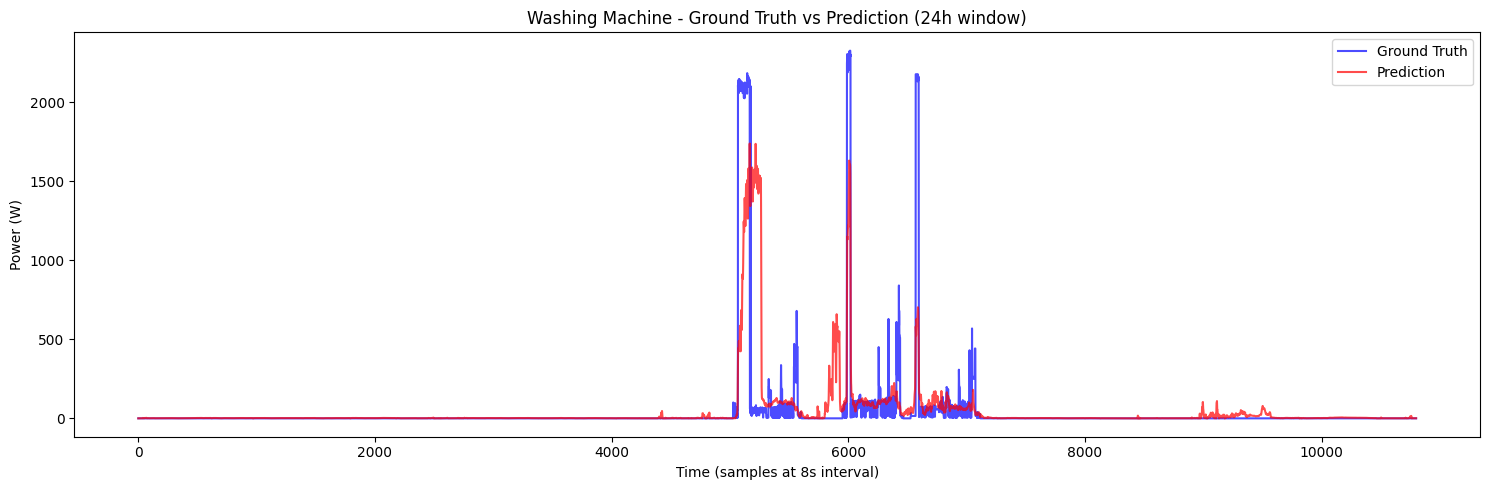


Metrics for Kettle:
  MAE:  6.86 W
  RMSE: 78.86 W
  F1 Score (> 2000W): 0.856


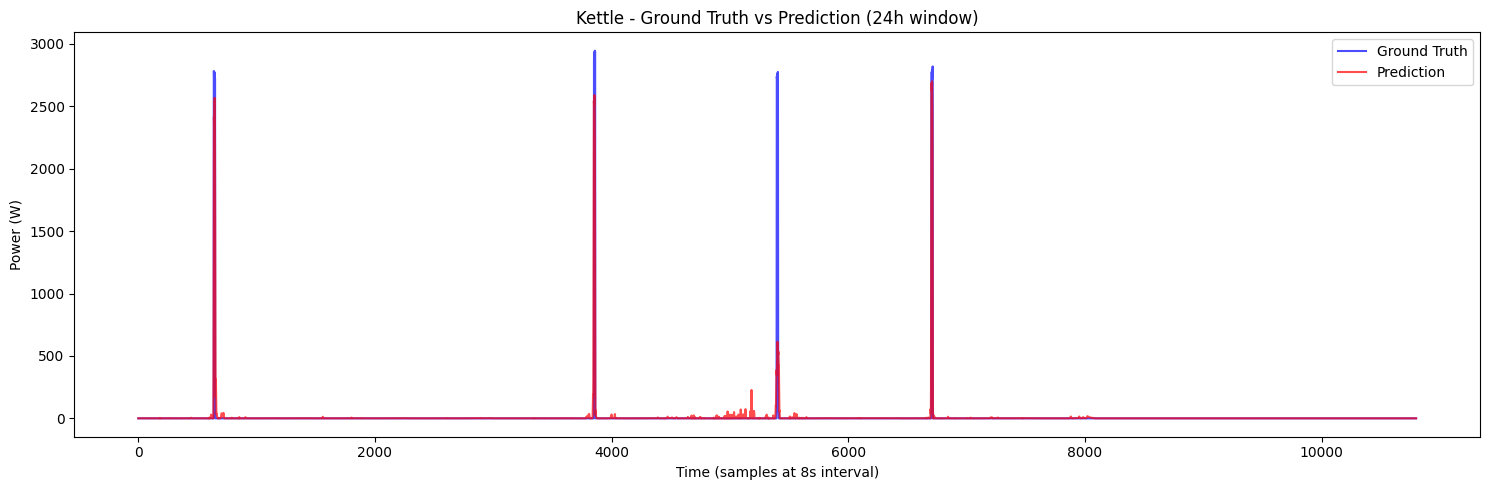

In [8]:
def evaluate_and_plot(model, test_loader, model_path, window_hours=24):
    print(f"\n--- Evaluating Multi-Target Model ---")
    model.load_state_dict(torch.load(model_path))
    model.eval()
    
    all_preds = []
    all_targets = []
    
    with torch.no_grad():
        for x_batch, y_batch in tqdm(test_loader, desc="Testing"):
            x_batch = x_batch.to(device)
            # Standard prediction without autocast for precision in testing
            preds = model(x_batch)
            all_preds.append(preds.cpu().numpy())
            all_targets.append(y_batch.numpy())
            
    all_preds = np.concatenate(all_preds, axis=0)
    all_targets = np.concatenate(all_targets, axis=0)
    
    # Clip predictions to remove negatives and cap at max
    for i, app_name in enumerate(CONFIG["target_appliances"]):
        max_p = CONFIG["appliances"][app_name]["max_power"]
        all_preds[:, i] = np.clip(all_preds[:, i], 0, max_p)
    
    # Metrics
    for i, app_name in enumerate(CONFIG["target_appliances"]):
        mae = mean_absolute_error(all_targets[:, i], all_preds[:, i])
        rmse = np.sqrt(mean_squared_error(all_targets[:, i], all_preds[:, i]))
        
        thresh = CONFIG["appliances"][app_name]["on_power_threshold"]
        target_on = (all_targets[:, i] >= thresh).astype(int)
        pred_on = (all_preds[:, i] >= thresh).astype(int)
        f1 = f1_score(target_on, pred_on)
        
        print(f"\nMetrics for {app_name}:")
        print(f"  MAE:  {mae:.2f} W")
        print(f"  RMSE: {rmse:.2f} W")
        print(f"  F1 Score (> {thresh}W): {f1:.3f}")
        
        # Plotting
        samples_per_hour = 3600 // int(CONFIG["resample_seconds"].replace('s', ''))
        plot_samples = window_hours * samples_per_hour
        
        active_indices = np.where(all_targets[:, i] > thresh)[0]
        if len(active_indices) > 0:
            start_idx = max(0, active_indices[len(active_indices)//2] - plot_samples // 2)
        else:
            start_idx = 0
            
        end_idx = min(len(all_targets[:, i]), start_idx + plot_samples)
        
        plt.figure(figsize=(15, 5))
        plt.plot(all_targets[start_idx:end_idx, i], label='Ground Truth', color='blue', alpha=0.7)
        plt.plot(all_preds[start_idx:end_idx, i], label='Prediction', color='red', alpha=0.7)
        plt.title(f"{app_name} - Ground Truth vs Prediction ({window_hours}h window)")
        plt.xlabel(f"Time (samples at {CONFIG['resample_seconds']} interval)")
        plt.ylabel("Power (W)")
        plt.legend()
        plt.tight_layout()
        plt.savefig(f"multi_{app_name.replace(' ', '_').lower()}_results.png")
        plt.show()

# Evaluate
evaluate_and_plot(model, test_loader, model_path)
